In [1]:
# Install hypertools (run this first on Colab)
import importlib.util
if importlib.util.find_spec('hypertools') is None:
    %pip install -q "hypertools[interactive]"

# News headlines in embedding space: a Hugging Face dataset meets sentence transformers

Modern language models turn text into high-dimensional embedding vectors -- a perfect
match for HyperTools! In this tutorial we'll embed news headlines from a
[Hugging Face](https://huggingface.co) dataset using a small
[sentence-transformers](https://www.sbert.net) model, and then use HyperTools to
explore the embedding space.

Both the dataset loader and the sentence-embedding model come from
HyperTools' `[text]` extra, which HyperTools installs on demand the first
time it is needed: `hyp.load` streams the dataset straight from the Hugging
Face Hub, and `hyp.plot` embeds the text. (The companion
[Wikipedia tutorial](wikipedia_embeddings.ipynb) uses the same embedding
route on a document corpus, and adds an animated spin and a density overlay;
this one focuses on a labeled dataset and on what the labels reveal.)

In [1]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'

# the environment variables above must be set before importing the
# libraries that read them, so this import is intentionally not at the
# top of the cell.
import hypertools as hyp  # noqa: E402

## Embedding news headlines

We'll use a small sample (400 headlines) from the
[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) dataset, which contains news
headlines from four categories: World, Sports, Business, and Sci/Tech.  To turn
each headline into a vector we'll use
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-embedding model that maps each document onto a 384-dimensional
vector.

`hyp.load` accepts any Hugging Face dataset id. With `streaming=True` it
returns the `datasets.IterableDataset` itself, which still carries the
dataset's own label names (`features['label'].names`); a plain load would
return a DataFrame with the labels as integers. We shuffle the stream with a
fixed seed and take 400 rows, so the sample mixes all four categories.

HyperTools does the embedding itself: every `hyp.plot` call below takes the raw headlines together with `vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None`, which hands the text straight to that sentence-transformers model (`semantic=None` skips the topic-model stage HyperTools applies to text by default). Encoding 400 headlines takes about a second, so re-encoding per call costs less than carrying an embedding matrix around.

In [2]:
# a streaming load keeps the dataset's own label names; a plain (non-streaming)
# load returns a DataFrame with integer labels instead
news = hyp.load('fancyzhx/ag_news', split='train', streaming=True)
label_names = news.features['label'].names

sample = list(news.shuffle(seed=42, buffer_size=2000).take(400))   # a mixed 400-headline sample
headlines = [row['text'] for row in sample]
categories = [label_names[row['label']] for row in sample]
print(len(headlines), 'headlines across', sorted(set(categories)))

400 headlines across ['Business', 'Sci/Tech', 'Sports', 'World']


## Plotting the embedding space

Passing the category labels via the `hue` argument colors each headline by its
news category, and `legend=True` labels those groups (it derives the group
names from `hue` itself, in order of first appearance).
HyperTools embeds the headlines and reduces the 384-dimensional embeddings to 3D (using incremental PCA
by default) before plotting.

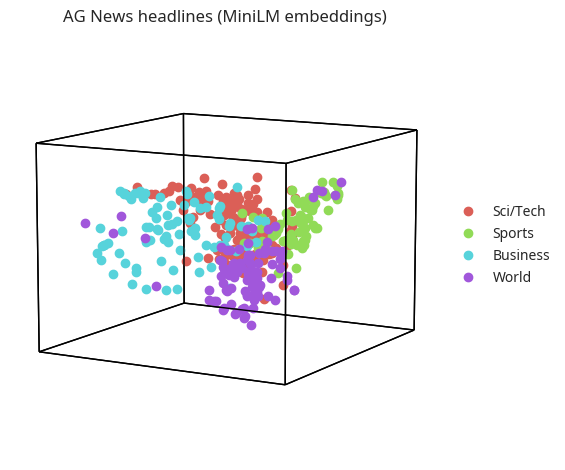

In [3]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               hue=categories, legend=True,
               title='AG News headlines (MiniLM embeddings)')

Even in three dimensions, headlines from the same category tend to occupy the
same part of the embedding space.

## Soft clustering with Gaussian mixture models

What if we didn't know the category labels? We can discover structure directly
from the embeddings.  Setting `cluster='GaussianMixture'` fits a mixture model
and colors each observation by its *blend* of cluster memberships -- points
that sit between clusters get intermediate colors, revealing the soft category
boundaries.

We pass `n_clusters=4` to match the four known AG News categories; for a mixture model HyperTools forwards that count as `n_components`. The mixture is fit to the 3-D reduced coordinates that get drawn, not to the raw 384-dimensional vectors, and each point's color reflects its cluster membership.

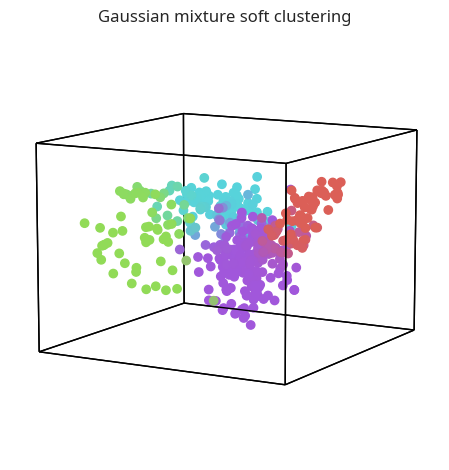

In [4]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               cluster='GaussianMixture', n_clusters=4,
               title='Gaussian mixture soft clustering')

## Nonlinear embeddings with UMAP

PCA is linear; nonlinear methods like [UMAP](https://umap-learn.readthedocs.io)
can often do a better job of untangling text embeddings.  Just pass
`reduce='UMAP'`:

`ndims=2` asks for a flat 2-D projection instead of the default 3. UMAP is stochastic and is left unseeded here, so the layout differs from run to run; pass `reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}}` to fix it in place.

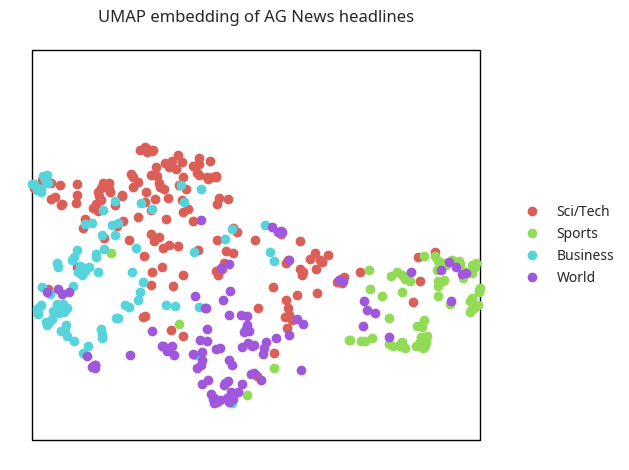

In [5]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               reduce='UMAP', ndims=2,
               hue=categories, legend=True,
               title='UMAP embedding of AG News headlines')

## Next steps

Try swapping in a different Hugging Face dataset or embedding model, aligning
embeddings from *two* models with `hyp.align`, or exploring interactive 3D
plots with `backend='plotly'`. For an animated tour of an embedding map
(`animate='spin'`) and a volumetric density overlay, see the
[Wikipedia tutorial](wikipedia_embeddings.ipynb).